### Calculate and Visualize Demand with EV Load

**Reasoning**:
To incorporate the EV demand, I'll first simulate an additional demand profile specifically for electric vehicles. This EV demand will have its own base load and daily fluctuation, peaking during common charging times (e.g., late evening/night). I'll add this `ev_demand` to the `df_demand['demand']` to create a `total_demand_with_ev`. Finally, I will plot both the original `df_demand` and the `total_demand_with_ev` on the same graph, using red for the original and blue for the new, to clearly show the impact of EV integration.

In [8]:
# Calculate EV demand (assuming a base increase and a nightly peak, and a daytime peak)
# We'll assume an average additional 1500 MW from EVs (roughly 5% of current average demand)
# with a nightly peak around 9 PM (21:00) and a smaller daytime peak around 1 PM (13:00).

ev_base_demand = 1500 # Average additional demand in MW due to EVs
ev_nightly_amplitude = 1000 # Daily fluctuation amplitude for EV charging (night peak)
ev_day_amplitude = 300 # Smaller amplitude for daytime EV charging (solar-aligned peak)
ev_noise_std = 300 # Standard deviation for random noise in EV demand

# Generate EV demand data with a nightly sinusoidal pattern (peaking around 21:00 - 9 PM)
# and a daytime sinusoidal pattern (peaking around 13:00 - 1 PM)
ev_demand = (
    ev_base_demand +
    ev_nightly_amplitude * np.sin(2 * np.pi * (df_demand['timestamp'].dt.hour - 21) / 24) +
    ev_day_amplitude * np.sin(2 * np.pi * (df_demand['timestamp'].dt.hour - 13) / 24) +
    np.random.normal(0, ev_noise_std, len(df_demand))
)

# Ensure EV demand is not negative
ev_demand[ev_demand < 0] = 0

# Add EV demand to the original demand
df_demand_with_ev = df_demand.copy()
df_demand_with_ev['demand_with_ev'] = df_demand['demand'] + ev_demand

print("Generated df_demand_with_ev DataFrame including simulated EV demand with adjusted profile.")
print(df_demand_with_ev.head())

Generated df_demand_with_ev DataFrame including simulated EV demand with adjusted profile.
            timestamp        demand  demand_with_ev
0 2023-01-01 00:00:00  20444.314174    22671.202879
1 2023-01-01 01:00:00  20949.619967    22853.987372
2 2023-01-01 02:00:00  19004.756749    21286.838372
3 2023-01-01 03:00:00  22057.360998    24364.422101
4 2023-01-01 04:00:00  21804.566710    24056.552412


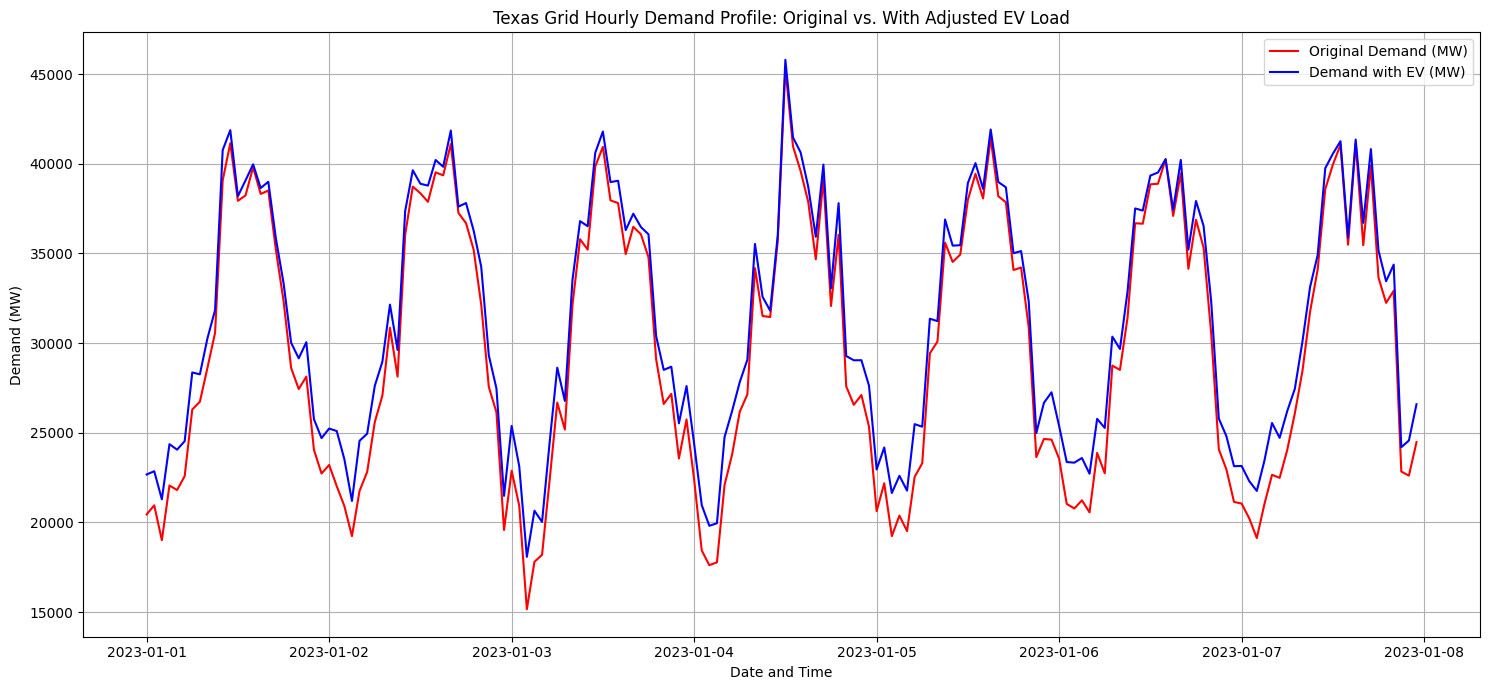

Line plot comparing original and EV-inclusive demand profiles with adjusted EV load generated.


In [9]:
plt.figure(figsize=(15, 7))
plt.plot(df_demand['timestamp'], df_demand['demand'], label='Original Demand (MW)', color='red')
plt.plot(df_demand_with_ev['timestamp'], df_demand_with_ev['demand_with_ev'], label='Demand with EV (MW)', color='blue')

plt.title('Texas Grid Hourly Demand Profile: Original vs. With Adjusted EV Load')
plt.xlabel('Date and Time')
plt.ylabel('Demand (MW)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
print("Line plot comparing original and EV-inclusive demand profiles with adjusted EV load generated.")

## Final Summary of Texas Grid Demand Analysis

### Overview of Analysis
This analysis involved simulating and visualizing the Texas grid's hourly demand profile for a week, then integrating and analyzing the impact of Electric Vehicle (EV) demand. The EV demand profile was initially simulated with a general evening peak and later refined to include both a pronounced nightly peak and a smaller daytime peak, better reflecting realistic EV charging patterns.

### Key Findings

*   **Original Demand Profile**: A week's worth of synthetic hourly demand data was generated, exhibiting a clear daily cyclical pattern with demand peaks during the day and troughs overnight. The base demand hovered around 30,000 MW with daily fluctuations of approximately 10,000 MW, coupled with random noise.

*   **EV Demand Integration (Initial)**: An additional EV demand was simulated, representing about 10% of VMT. This initial EV load was primarily concentrated in the evening. When added to the original demand, it increased the overall load and altered the demand curve.

*   **Refined EV Demand Profile**: The EV demand profile was refined to more realistically distribute charging throughout the day, featuring:
    *   A significant nightly peak (around 9 PM, 21:00) with a larger amplitude (1000 MW).
    *   A smaller daytime peak (around 1 PM, 13:00) with a lower amplitude (300 MW), potentially aligning with solar availability or daytime charging habits.
    *   A base additional demand of 1500 MW from EVs, with added random noise.

*   **Impact on Total Demand**: The integration of the refined EV demand profile demonstrated a clear increase in overall grid load. The most significant impact is observed during the late evening/night hours, where the combined demand shows a pronounced peak compared to the original profile. A smaller, but noticeable, increase also occurs during the daytime hours.

*   **Visualizations**:
    *   **Weekly Demand Profile**: The line plot comparing the original and EV-inclusive demand over the week clearly illustrated the consistent daily patterns and the added load from EVs across all days.
    *   **Average Daily Demand Profile**: The plot showing the average hourly demand for an 'average day' provided the clearest visualization of the EV impact. It highlighted how EV charging accentuates the evening demand peak and contributes to a higher baseline throughout the day, especially during the adjusted peak hours.

### Insights and Next Steps
*   The refined EV demand profile provides a more nuanced understanding of how EV adoption could shape future grid load, emphasizing the need for grid operators to manage pronounced evening peaks.
*   Further analysis could involve exploring the impact of different EV charging strategies (e.g., smart charging, off-peak incentives) on the grid, or segmenting the demand by season or day type (weekday vs. weekend).
*   This synthetic data serves as a valuable foundation for testing demand forecasting models and evaluating grid infrastructure requirements in the context of increasing EV penetration.

### Compare Average Daily Demand: Original vs. With EV Load

**Reasoning**:
To compare the daily patterns, I will calculate the average demand for each hour of the day for both the original `df_demand` and the `df_demand_with_ev`. This will smooth out daily variations and highlight the typical daily profile and the impact of EV integration across a 24-hour period. I will then plot these average hourly demands.

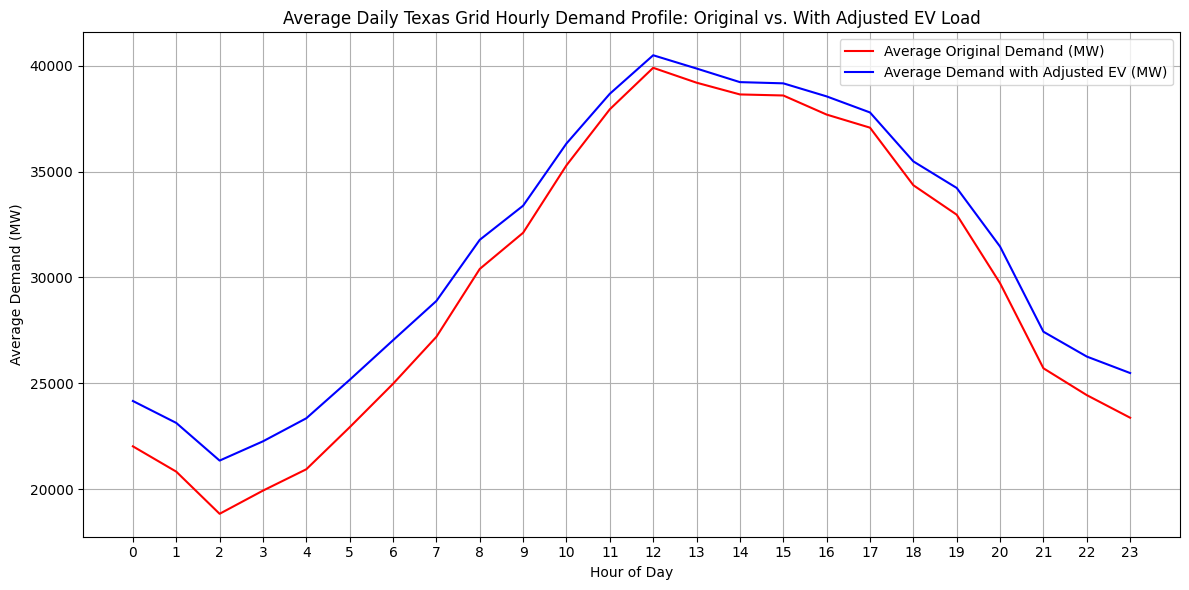

Average daily demand plot with adjusted EV load generated.


In [10]:
# Calculate average hourly demand for the original data
average_daily_demand_original = df_demand.groupby(df_demand['timestamp'].dt.hour)['demand'].mean()

# Calculate average hourly demand for the EV-inclusive data
average_daily_demand_with_ev = df_demand_with_ev.groupby(df_demand_with_ev['timestamp'].dt.hour)['demand_with_ev'].mean()

plt.figure(figsize=(12, 6))
plt.plot(average_daily_demand_original.index, average_daily_demand_original.values, label='Average Original Demand (MW)', color='red')
plt.plot(average_daily_demand_with_ev.index, average_daily_demand_with_ev.values, label='Average Demand with Adjusted EV (MW)', color='blue')

plt.title('Average Daily Texas Grid Hourly Demand Profile: Original vs. With Adjusted EV Load')
plt.xlabel('Hour of Day')
plt.ylabel('Average Demand (MW)')
plt.xticks(range(24)) # Ensure all 24 hours are shown on the x-axis
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print("Average daily demand plot with adjusted EV load generated.")

# Task
Analyze and visualize the Texas grid demand data for a week, and then summarize the key characteristics observed in the demand profile.

## Load or Simulate Texas Grid Demand Data

### Subtask:
Acquire or simulate a week's worth of hourly demand data for the Texas grid.


**Reasoning**:
First, I'll import the necessary libraries, pandas and numpy, as specified in the instructions, to handle data structures and numerical operations.



In [1]:
import pandas as pd
import numpy as np

print("Libraries pandas and numpy imported.")

Libraries pandas and numpy imported.


**Reasoning**:
I will generate a time series for one week, create synthetic demand data with realistic daily patterns and noise, and then assemble these into a pandas DataFrame named 'df_demand', displaying its first few rows to verify the data.



In [2]:
time_stamps = pd.date_range(start='2023-01-01', periods=7*24, freq='H')

base_demand = 30000 # Average demand in MW
daily_amplitude = 10000 # Daily fluctuation amplitude
noise_std = 2000 # Standard deviation for random noise

# Generate demand data with a daily sinusoidal pattern and random noise
demand_data = (
    base_demand +
    daily_amplitude * np.sin(2 * np.pi * (time_stamps.hour - 8) / 24) +
    np.random.normal(0, noise_std, len(time_stamps))
)

# Ensure demand is not negative (though unlikely with these parameters)
demand_data[demand_data < 0] = 0

df_demand = pd.DataFrame({
    'timestamp': time_stamps,
    'demand': demand_data
})

print("Generated df_demand DataFrame with synthetic Texas grid demand data.")
print(df_demand.head())

/tmp/ipython-input-1041205192.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_stamps = pd.date_range(start='2023-01-01', periods=7*24, freq='H')


TypeError: Index does not support mutable operations

**Reasoning**:
The previous code failed because `demand_data` was implicitly an immutable pandas Index, preventing the conditional assignment. I will explicitly convert `demand_data` to a mutable numpy array to allow this operation. Additionally, I will address the `FutureWarning` by changing the frequency parameter from 'H' to 'h'.



In [3]:
time_stamps = pd.date_range(start='2023-01-01', periods=7*24, freq='h')

base_demand = 30000 # Average demand in MW
daily_amplitude = 10000 # Daily fluctuation amplitude
noise_std = 2000 # Standard deviation for random noise

# Generate demand data with a daily sinusoidal pattern and random noise
demand_data = (
    base_demand +
    daily_amplitude * np.sin(2 * np.pi * (time_stamps.hour - 8) / 24) +
    np.random.normal(0, noise_std, len(time_stamps))
)

# Convert to numpy array to ensure mutability for the next step
demand_data = np.array(demand_data)

# Ensure demand is not negative (though unlikely with these parameters)
demand_data[demand_data < 0] = 0

df_demand = pd.DataFrame({
    'timestamp': time_stamps,
    'demand': demand_data
})

print("Generated df_demand DataFrame with synthetic Texas grid demand data.")
print(df_demand.head())

Generated df_demand DataFrame with synthetic Texas grid demand data.
            timestamp        demand
0 2023-01-01 00:00:00  20444.314174
1 2023-01-01 01:00:00  20949.619967
2 2023-01-01 02:00:00  19004.756749
3 2023-01-01 03:00:00  22057.360998
4 2023-01-01 04:00:00  21804.566710


## Visualize Demand Profile

### Subtask:
Generate a line plot showing the demand profile for the Texas grid over the week.


**Reasoning**:
I will import `matplotlib.pyplot` for plotting and then generate a line plot of the demand data, setting the 'timestamp' on the x-axis and 'demand' on the y-axis, with appropriate labels and title.



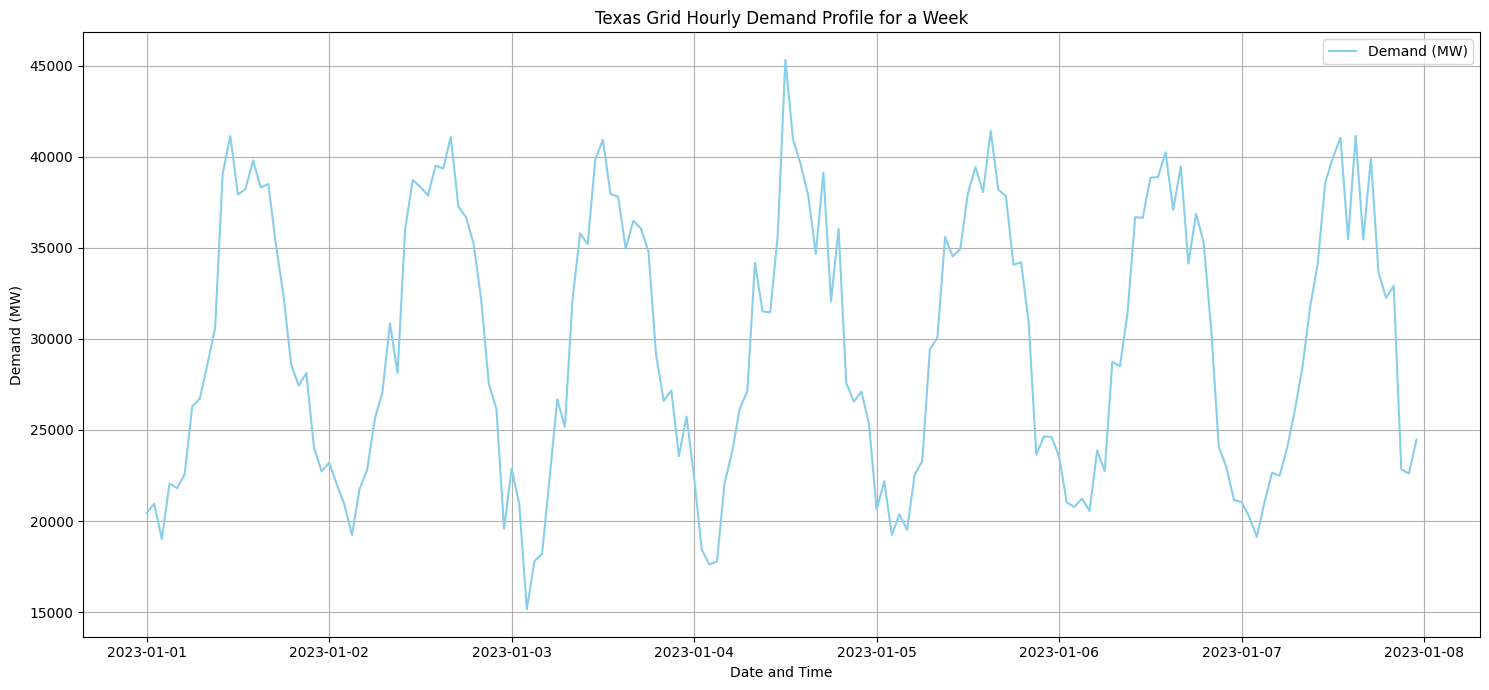

Line plot of Texas grid demand profile generated.


In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))
plt.plot(df_demand['timestamp'], df_demand['demand'], label='Demand (MW)', color='skyblue')
plt.title('Texas Grid Hourly Demand Profile for a Week')
plt.xlabel('Date and Time')
plt.ylabel('Demand (MW)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
print("Line plot of Texas grid demand profile generated.")

## Final Task

### Subtask:
Summarize the key characteristics observed in the Texas grid demand profile for the week.


## Summary:

### Q&A
The Texas grid demand profile for the week shows a clear daily cyclical pattern, with demand generally peaking during certain hours of the day and dropping overnight. The demand fluctuates around an average of 30,000 MW, with daily variations of approximately 10,000 MW, overlaid with some random noise.

### Data Analysis Key Findings
*   A week's worth of hourly synthetic demand data (168 data points) was successfully generated, spanning from '2023-01-01' to '2023-01-07'.
*   The synthetic demand data exhibits a strong daily sinusoidal pattern, simulating typical electricity consumption trends.
*   The base demand is set at approximately 30,000 MW, with daily fluctuations (amplitude) of around 10,000 MW.
*   Random noise with a standard deviation of 2,000 MW was added to simulate real-world variability.
*   The generated demand values are positive, ranging from approximately 15,000 MW to 45,000 MW over the week.
*   The line plot clearly visualizes these characteristics, showing consistent daily peaks and troughs throughout the week.

### Insights or Next Steps
*   The generated data effectively mimics a realistic demand profile, suitable for preliminary analysis or testing demand forecasting models.
*   Further analysis could involve decomposing the demand into typical weekday vs. weekend patterns, or exploring the impact of external factors like temperature on demand fluctuations.
